#Major Project: Animal Classification
In this project we will classify between dogs and cats.

In [ ]:
# Import all of the necesary
import tensorflow as tf
import cv2 as cv

# import the dataset from kaggle
!pip install kaggle
!mkdir ~/.kaggle

In [ ]:
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
 98% 213M/218M [00:00<00:00, 434MB/s]
100% 218M/218M [00:00<00:00, 421MB/s]


In [ ]:
# unzip data
import zipfile as zip
with zip.ZipFile("/content/cat-and-dog.zip", 'r') as f:
    f.extractall()

In [ ]:
# check data
import random
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def check_image(name="cats", return_img=False):
  """
  Function to randomly choose and see images from train folder
  """
  if name == "dogs":
    files = os.listdir("/content/training_set/training_set/dogs")
  else:
    files = os.listdir("/content/training_set/training_set/cats")
  length = len(files)
  r = random.randint(0,length-1)
  img = mpimg.imread("/content/training_set/training_set/" + name + "/" + files[r])

  if not return_img:
    plt.imshow(img)
    print(img.shape)
  else:
    return img

(197, 265, 3)


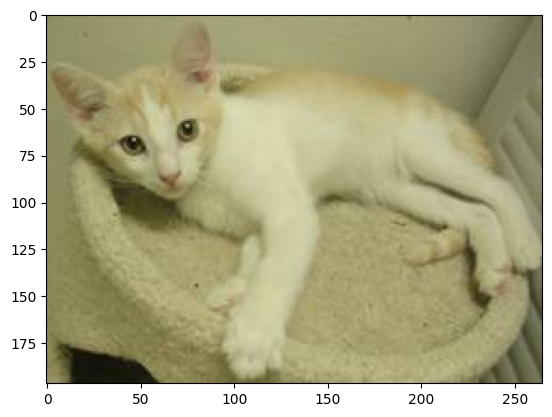

In [ ]:
check_image(name="cats")

In [ ]:
# load data into ram
# import data into batches
train_data_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1/255.0)

test_validate_data_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1/255.)

train_data = train_data_generator.flow_from_directory(directory="/content/training_set/training_set",
                                                      batch_size=32,
                                                      target_size=(256,256),
                                                      class_mode="binary",
                                                      seed=16)

val_data = test_validate_data_generator.flow_from_directory(directory="/content/test_set/test_set",
                                                      batch_size=32,
                                                      target_size=(256,256),
                                                      class_mode="binary",
                                                      seed=16)

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


In [ ]:
"""
Input Layer : (256, 256, 3) -> (x, y, z)
Hidden Layer:
 - conv2d
 - conv2d
 - maxpool2d
 - conv2d
 - maxpool2d
 - flatten
Output Layer: 1 (dog + cat)
"""
model_1 = tf.keras.Sequential([
    # inpput layer
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Hidden layers
    tf.keras.layers.Conv2D(64, (1, 1), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Fully connected layers
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),  # Regularization
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer
])

# Compile the model
model_1.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["accuracy"]
)

steps_per_epoch = train_data.samples // train_data.batch_size
validation_steps = val_data.samples // val_data.batch_size

# Train the model
base_history = model_1.fit(
    train_data,
    epochs=10,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_data,
    validation_steps=validation_steps
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 107ms/step - accuracy: 0.5349 - loss: 0.6908 - val_accuracy: 0.6815 - val_loss: 0.6285
Epoch 2/10
  1/250 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.6562 - loss: 0.6544

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6562 - loss: 0.6544 - val_accuracy: 0.6781 - val_loss: 0.6283
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 89ms/step - accuracy: 0.6590 - loss: 0.6217 - val_accuracy: 0.7153 - val_loss: 0.5680
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6875 - loss: 0.7585 - val_accuracy: 0.7257 - val_loss: 0.5639
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 162ms/step - accuracy: 0.7034 - loss: 0.5768 - val_accuracy: 0.7450 - val_loss: 0.5370
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7500 - loss: 0.5622 - val_accuracy: 0.7445 - val_loss: 0.5377
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 98ms/step - accuracy: 0.7291 - loss: 0.5376 - val_accuracy: 0.7470 - val_loss: 0.5321
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9062 - loss: 0.4413 - val_accuracy: 0.7450 - val_loss: 0.5319
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - accuracy: 0.7437 - loss: 0.5217 - val_accuracy:

In [ ]:
# get image from url
from PIL import Image
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt

def predict_from_url(url):
  response = requests.get(url)
  img = Image.open(BytesIO(response.content))

  # resize image
  img_ = np.array(img)
  img_ = tf.image.resize(img, [256, 256])
  img_ = img_ / 255.0  # Normalize pixel values to [0, 1]
  img_ = np.expand_dims(img_, axis=0)  # Shape becomes (1, 512, 512, 3)
  print(img_.shape)

  # predict with new image
  prediction = model_1.predict(img_)

  if prediction < 0.5:
    print("This is a cat!")
  else:
    print("This is a dog!")
  print(prediction)

  # display image
  img = Image.open(BytesIO(response.content))
  plt.imshow(img)
  plt.show()

(1, 256, 256, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
This is a cat!
[[0.47078314]]


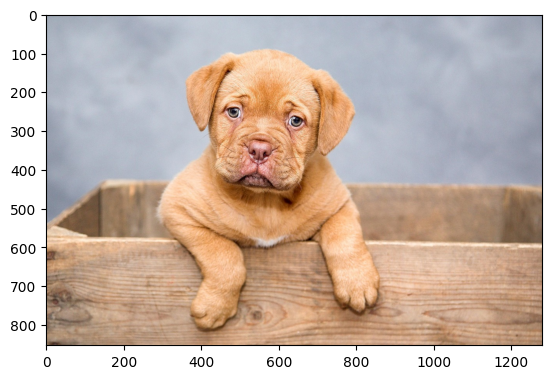

In [ ]:
predict_from_url("https://cdn.pixabay.com/photo/2015/11/17/13/13/puppy-1047521_1280.jpg")